# cable Workflow

推荐入口 notebook：选择一个主配置 JSON，运行该 config 声明的全部模板，并完成 config 级 summary 与模板级 case 钻取。


In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
from IPython.display import display

# 向上遍历文件系统，定位包含 braincell 和 examples 目录的项目根目录
def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

REPO_ROOT = find_repo_root()
CABLE_ROOT = REPO_ROOT / "examples" / "neuron_compare" / "cable"
WORKFLOWS_ROOT = CABLE_ROOT / "workflows"

# 将局部 workflows 目录添加到 Python 路径，以便导入同目录下的 workflow_api 模块
if str(WORKFLOWS_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKFLOWS_ROOT))

import workflow_api
import brainstate
brainstate.environ.set(precision=64)

ERROR:2026-04-26 14:47:27,089:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/swl/braincell/examples/neuron_compare/cable/engine/run.py", line 12, in <module>
    from .compare import compare_case
ImportError: attempted relative import with no known parent package

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/swl/braincell/examples/neuron_compare/cable/engine/compare.py", line 12, in <module>
    from .braincell_runner import run_case as run_braincell_case
ImportError: attempted relative import with no known parent package

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home

## Parameters

这里只手动设置主配置路径和是否生成图。模板列表由 config 自己声明。


In [2]:
config_path = CABLE_ROOT / "configs" / "IO.json"
plot_cases = True


## Input Preview

In [3]:
inputs = workflow_api.load_config_workflow_inputs(config_path)
print("config_path:", inputs["config_path"])
print("config_name:", inputs["config_name"])
print("template_names:", inputs["template_names"])
print("n_templates:", inputs["n_templates"])
print("default_out_dir:", inputs["default_out_dir"])


config_path: /home/swl/braincell/examples/neuron_compare/cable/configs/IO.json
config_name: IO
template_names: ('ac', 'dc', 'vinit', 'cv')
n_templates: 4
default_out_dir: /home/swl/braincell/examples/neuron_compare/cable/results/config_runs/IO


## Run Workflow

In [4]:
run_info = workflow_api.run_notebook_config_workflow(
    config_path=config_path,
    out_dir=None,
    plot=plot_cases,
    expand_only=False,
    raise_on_failure=False,
)

print("status:", run_info["status"])
print("config_name:", run_info["config_name"])
print("out_dir:", run_info["out_dir"])
print("n_templates:", run_info["n_templates"])
print(json.dumps(run_info["status_counts"], indent=2, ensure_ascii=False))

template_run = next(
    (row for row in run_info["template_runs"] if row["batch_status"] in {"ok", "partial"}),
    None,
)
if template_run is None:
    raise RuntimeError("No successful template run; check failures.csv in the output directory.")

template_out_dir = Path(template_run["out_dir"])
tables = workflow_api.build_summary_tables(template_out_dir)
print("template_name:", template_run["template_name"])
print("template_out_dir:", template_out_dir)


--No graphics will be displayed.


status: 0
config_name: IO
out_dir: /home/swl/braincell/examples/neuron_compare/cable/results/config_runs/IO
n_templates: 4
{
  "ok": 4,
  "partial": 0,
  "failed": 0
}
template_name: ac
template_out_dir: /home/swl/braincell/examples/neuron_compare/cable/results/config_runs/IO/templates/ac


,observable,n_rows,n_cases,mae_mean,rmse_mean,max_abs_max,rel_mae_pct_mean
0,voltage_sum,9,9,1.948365e-08,2.706180e-08,1.620310e-07,3.230939e-10
1,voltage_midpoint_mean,9,9,7.269147e-10,8.708447e-10,3.559226e-09,1.120930e-09


,case_id,group_id,observable,mae,rmse,max_abs,rel_mae_pct
0,ac__008,ac,voltage_sum,5.107315e-08,7.330145e-08,1.620310e-07,8.486954e-10
1,ac__007,ac,voltage_sum,2.778947e-08,4.062805e-08,9.905852e-08,4.609920e-10
2,ac__005,ac,voltage_sum,2.817774e-08,3.969090e-08,8.647476e-08,4.671824e-10
3,ac__004,ac,voltage_sum,1.673782e-08,2.333809e-08,5.498623e-08,2.772725e-10
4,ac__002,ac,voltage_sum,1.468267e-08,1.958376e-08,4.114372e-08,2.431079e-10
5,ac__006,ac,voltage_sum,1.140755e-08,1.511922e-08,3.436344e-08,1.888524e-10
6,ac__001,ac,voltage_sum,1.010631e-08,1.306022e-08,2.854995e-08,1.672776e-10
7,ac__003,ac,voltage_sum,8.547465e-09,1.070845e-08,2.264460e-08,1.414504e-10
8,ac__000,ac,voltage_sum,6.830714e-09,8.126093e-09,1.560784e-08,1.130147e-10
9,ac__008,ac,voltage_midpoint_mean,2.059606e-09,2.407511e-09,3.559226e-09,3.181135e-09


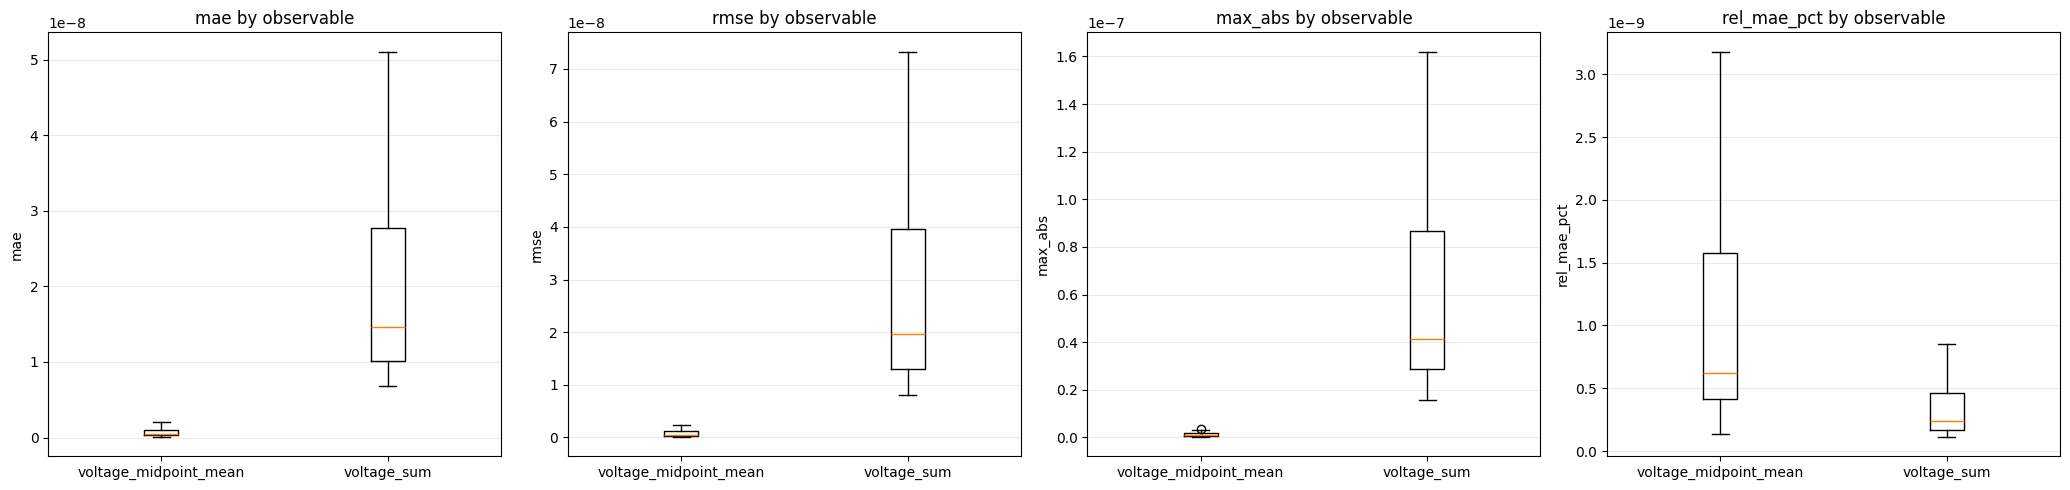

In [5]:
display(tables["by_observable_df"])

worst_columns = ["case_id", "group_id", "observable", "mae", "rmse", "max_abs", "rel_mae_pct"]
display(tables["worst_cases_df"][worst_columns].head(10))

if not tables["failed_df"].empty:
    display(tables["failed_df"][["case_id", "group_id", "error_message"]].drop_duplicates())

workflow_api.plot_observable_metric_boxplots(tables)
plt.show()


worst_case_id: ac__008


,compartment_index,mae,max_abs,rel_mae_pct,rmse,braincell_label,neuron_label,braincell_canonical_name,neuron_canonical_name
0,34,8.115200e-09,1.333225e-08,1.252813e-08,9.414388e-09,dend[5]:cv1,dend[5]:seg1,dend[5],dend[5]
1,35,7.974746e-09,1.347172e-08,1.230891e-08,9.382236e-09,dend[5]:cv2,dend[5]:seg2,dend[5],dend[5]
2,32,7.896045e-09,1.436874e-08,1.218182e-08,9.584953e-09,dend[4]:cv2,dend[4]:seg2,dend[4],dend[4]
3,31,7.724630e-09,1.360019e-08,1.192014e-08,9.239319e-09,dend[4]:cv1,dend[4]:seg1,dend[4],dend[4]
4,26,7.705076e-09,1.281323e-08,1.189781e-08,8.914335e-09,dend[2]:cv2,dend[2]:seg2,dend[2],dend[2]
5,30,6.941343e-09,1.162796e-08,1.071638e-08,8.115003e-09,dend[4]:cv0,dend[4]:seg0,dend[4],dend[4]
6,25,6.476535e-09,1.050807e-08,1.000547e-08,7.358468e-09,dend[2]:cv1,dend[2]:seg1,dend[2],dend[2]
7,33,5.237575e-09,8.982980e-09,8.088029e-09,6.190787e-09,dend[5]:cv0,dend[5]:seg0,dend[5],dend[5]
8,62,5.102730e-09,8.238260e-09,7.886132e-09,5.746127e-09,dend[14]:cv2,dend[14]:seg2,dend[14],dend[14]
9,64,4.722810e-09,8.108856e-09,7.290228e-09,5.591960e-09,dend[15]:cv1,dend[15]:seg1,dend[15],dend[15]


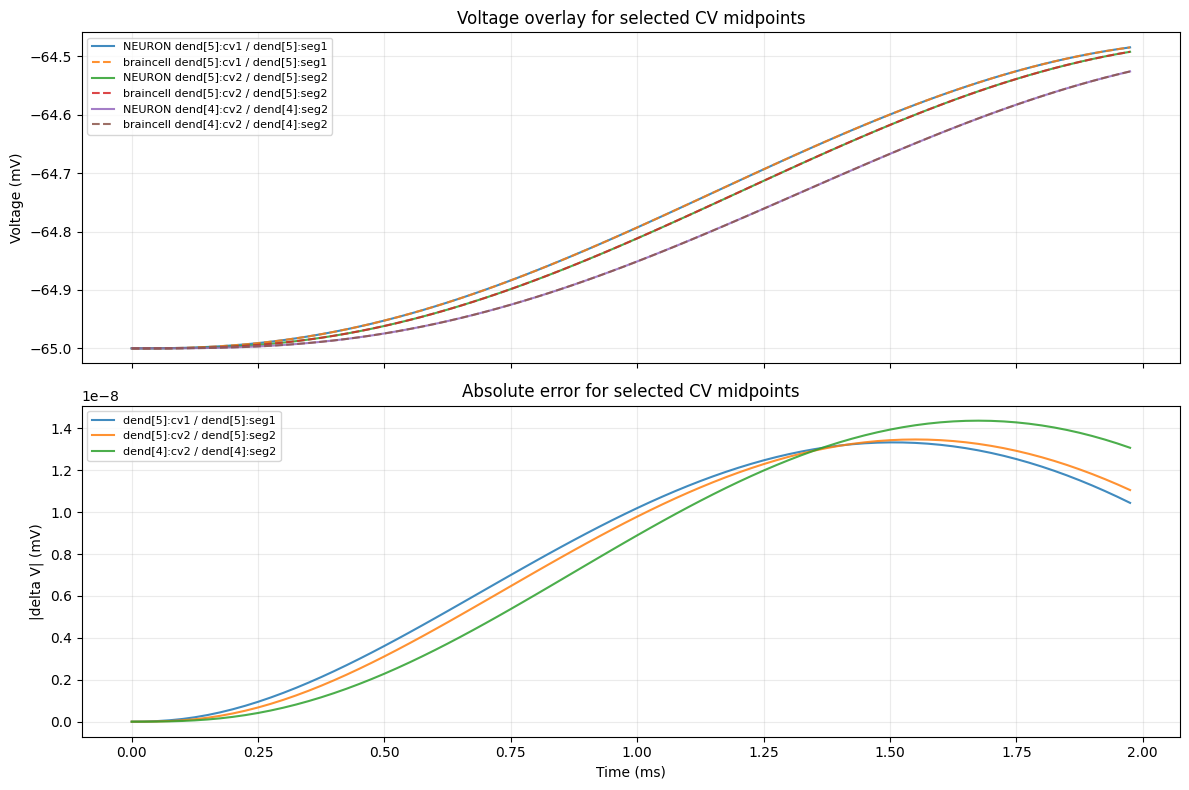

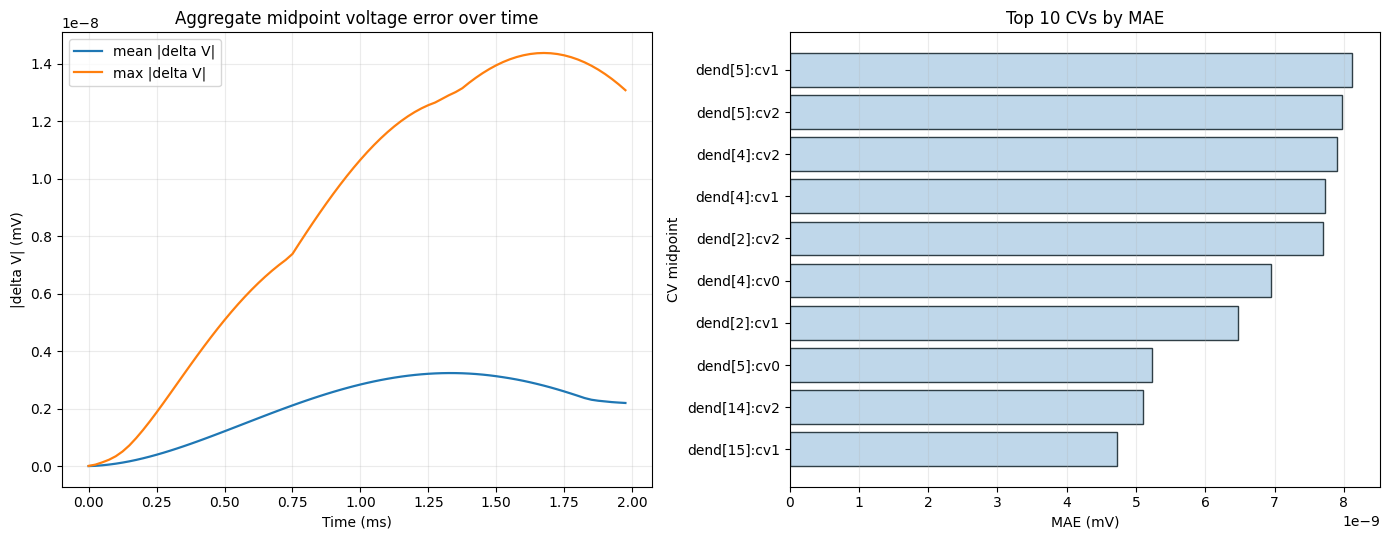

In [6]:
worst_case_id = tables["worst_cases_df"].iloc[0]["case_id"]
print("worst_case_id:", worst_case_id)

case_result = workflow_api.load_case_result(template_out_dir, worst_case_id)
case_metrics_df = workflow_api.build_case_metric_table(case_result)
display(case_metrics_df.head(10))

workflow_api.plot_case_overlay(case_result, max_compartments=3)
plt.show()

workflow_api.plot_case_error_summary(case_result, top_k=10)
plt.show()
